# Projeto Avaliativo - Machine Learning [T1]
## Opção A: Risco de Crédito (Setor Financeiro)

**Desafio de Negócio:** Qual o impacto financeiro para o banco se a máquina classificar um bom pagador como "Risco de Calote" (Falso Positivo) ou um mau pagador como "Seguro" (Falso Negativo)?

### Instalação de dependências e importação de bibliotecas

In [ ]:
!pip install -r requirements.txt -q

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Download e Leitura da Base de Dados

In [19]:
# Baixar do Google Drive usando gdown
!gdown 1R4WCMc_56lv3fMaDalUBAz5jSxeZOcwI -O credit_risk_dataset.csv

df = pd.read_csv('credit_risk_dataset.csv')
df.head()

Downloading...
From: https://drive.google.com/uc?id=1R4WCMc_56lv3fMaDalUBAz5jSxeZOcwI
To: c:\Users\leand\OneDrive\Documentos\Avaliativa\credit_risk_dataset.csv

  0%|          | 0.00/1.80M [00:00<?, ?B/s]
 29%|██▉       | 524k/1.80M [00:00<00:01, 978kB/s]
 58%|█████▊    | 1.05M/1.80M [00:01<00:00, 1.03MB/s]
 87%|████████▋ | 1.57M/1.80M [00:01<00:00, 1.08MB/s]
100%|██████████| 1.80M/1.80M [00:01<00:00, 1.10MB/s]
100%|██████████| 1.80M/1.80M [00:01<00:00, 1.07MB/s]


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


---
## Fase 1: Análise Exploratória de Dados (EDA)

### Descritiva e Estatística
Tamanho da base, tipos de dados e sumário estatístico.

In [20]:
print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")

Linhas: 32581 | Colunas: 12


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [22]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


### Visual
Gráficos explicativos sobre a distribuição dos dados e correlações.

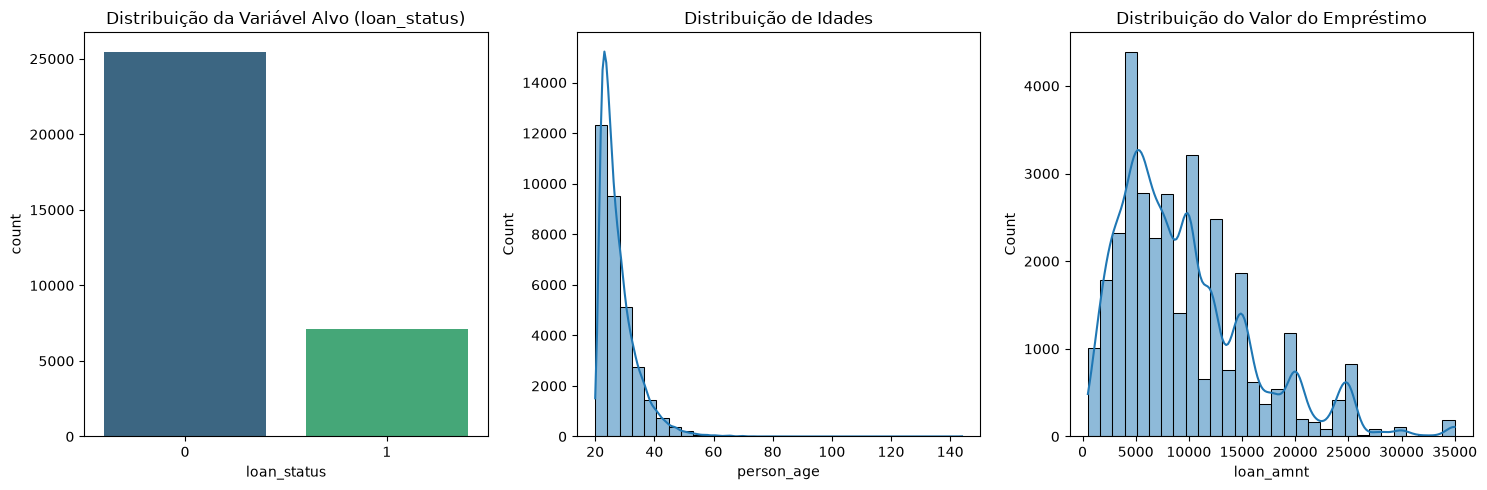

In [23]:
plt.figure(figsize=(15, 5))

# Gráfico 1: Desbalanceamento da variável alvo
plt.subplot(1, 3, 1)
sns.countplot(data=df, x='loan_status', palette='viridis')
plt.title('Distribuição da Variável Alvo (loan_status)')

# Gráfico 2: Distribuição das idades
plt.subplot(1, 3, 2)
sns.histplot(data=df, x='person_age', bins=30, kde=True)
plt.title('Distribuição de Idades')

# Gráfico 3: Distribuição dos valores de empréstimo
plt.subplot(1, 3, 3)
sns.histplot(data=df, x='loan_amnt', bins=30, kde=True)
plt.title('Distribuição do Valor do Empréstimo')

plt.tight_layout()
plt.show()

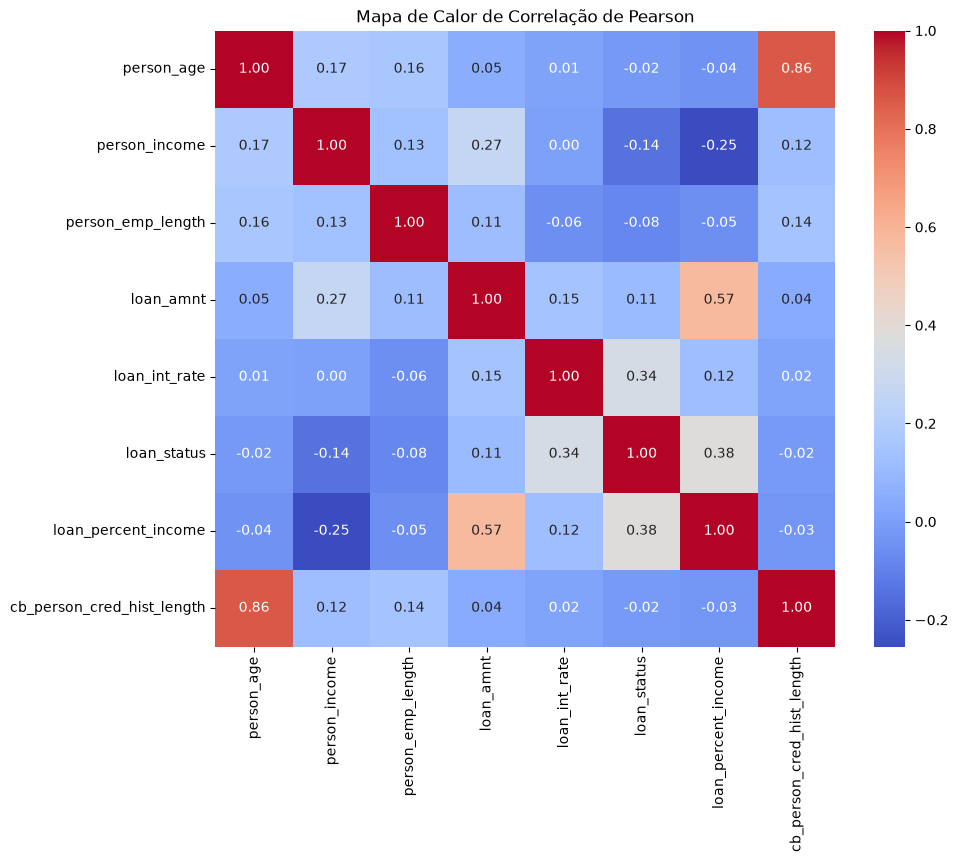

In [24]:
# Gráfico 4: Mapa de calor de correlação
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor de Correlação de Pearson')
plt.show()

### Tomada de Decisão (Insights da EDA)
**Parágrafo analítico:** A análise exploratória revelou que nossa base possui 32581 linhas, apresentando um desbalanceamento significativo na variável alvo (`loan_status`), o que exigirá técnicas de reamostragem (como SMOTE ou RandomUnderSampler) na fase de modelagem para evitar que o modelo fique viciado na classe majoritária. As distribuições numéricas (idade, renda) são assimétricas (right-skewed) e exibem valores máximos discrepantes, o que indica a presença forte de outliers, justificando o uso de Mediana para uma possível imputação de nulos e demandando tratamento cuidadoso (remoção ou clipping) para não prejudicar algoritmos sensíveis à distância como o KNN.

---
## Fase 2: Tratamento e Limpeza (Data Prep)

### Duplicadas
Identificação e remoção de linhas duplicadas.

In [25]:
print(f"Linhas duplicadas antes: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Linhas duplicadas depois: {df.duplicated().sum()}")
print(f"Novo tamanho da base: {df.shape}")

Linhas duplicadas antes: 165
Linhas duplicadas depois: 0
Novo tamanho da base: (32416, 12)


### Valores Nulos
Identificação e imputação de valores ausentes.

In [26]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              887
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3095
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

**Justificativa de Imputação:** Como as variáveis `person_emp_length` e `loan_int_rate` possuem dados faltantes e suas distribuições tendem a ter assimetria e outliers, utilizarei a **Mediana** para a imputação. A mediana é robusta a outliers, mitigando o impacto de valores atípicos que distorceriam a média caso fosse utilizada.

In [27]:
# Imputação pela mediana
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

print("Nulos após tratamento:")
print(df.isnull().sum())

Nulos após tratamento:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


### Tratamento de Outliers
Identificação e tratamento de valores discrepantes.

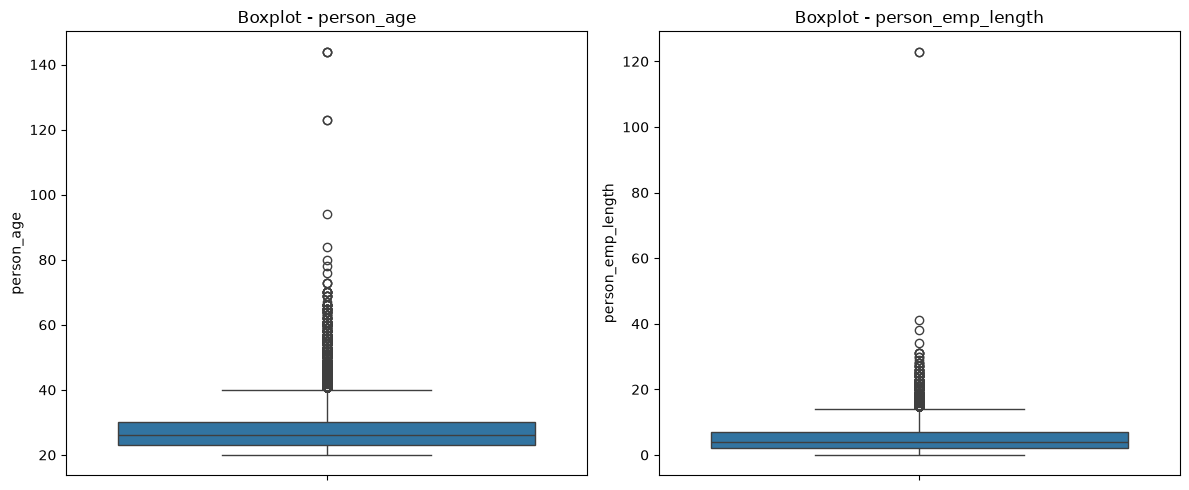

In [28]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['person_age'])
plt.title('Boxplot - person_age')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['person_emp_length'])
plt.title('Boxplot - person_emp_length')

plt.tight_layout()
plt.show()

**Decisão sobre Outliers:** Foram identificadas idades superiores a 120 anos e tempo de emprego superior a 120 anos (claros erros de inserção). Decidi pela **remoção** das linhas com idade > 100 ou tempo de emprego > 60. Como o **KNN é extremamente sensível a outliers** (pois eles distorcem o cálculo das distâncias euclidianas), essa remoção é essencial para a estabilidade do modelo. A Árvore de Decisão seria mais robusta a eles, mas o KNN exige essa mitigação.

In [29]:
# Removendo outliers extremos
df = df[df['person_age'] <= 100]
df = df[df['person_emp_length'] <= 60]

print(f"Tamanho da base após remoção de outliers: {df.shape}")

Tamanho da base após remoção de outliers: (32409, 12)


---
## Fase 3: Feature Engineering (Coluna Calculada)

In [30]:
# Verificando nulos nas colunas base antes do cálculo matemático
print("Nulos em loan_amnt:", df['loan_amnt'].isnull().sum())
print("Nulos em person_income:", df['person_income'].isnull().sum())

# Criação da coluna calculada: comprometimento_renda
df['comprometimento_renda'] = (df['loan_amnt'] / df['person_income']) * 100

print("\nEstatísticas da nova coluna (comprometimento_renda):")
print(df['comprometimento_renda'].describe())

Nulos em loan_amnt: 0
Nulos em person_income: 0

Estatísticas da nova coluna (comprometimento_renda):
count    32409.000000
mean        17.059651
std         10.705381
min          0.078947
25%          8.972231
50%         14.814815
75%         22.916667
max         83.000000
Name: comprometimento_renda, dtype: float64


---
## Fase 4: Separação, Balanceamento e Escalonamento Seguro

### Encoding
Conversão de colunas categóricas para numéricas.

In [31]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
cols_categoricas = df_encoded.select_dtypes(include=['object']).columns

le = LabelEncoder()
for col in cols_categoricas:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("Colunas categóricas codificadas:", cols_categoricas.tolist())

Colunas categóricas codificadas: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


### Split de Dados
Separação das variáveis preditoras (X) do alvo (y) e divisão Treino/Teste.

In [32]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

# stratify=y garante que a proporção de inadimplentes seja a mesma no Treino e no Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

print("Tamanho do Treino:", X_train.shape)
print("Tamanho do Teste:", X_test.shape)

Tamanho do Treino: (25927, 12)
Tamanho do Teste: (6482, 12)


### Balanceamento de Classes
Como a base é desbalanceada, usaremos RandomUnderSampler. **Regra de Ouro:** O balanceamento deve ser aplicado *estritamente e apenas* nos dados de Treino para evitar vazamento de dados (Data Leakage).

In [33]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_bal, y_train_bal = rus.fit_resample(X_train, y_train)

print("Distribuição da variável alvo APÓS balanceamento (TREINO):\n", y_train_bal.value_counts())

Distribuição da variável alvo APÓS balanceamento (TREINO):
 loan_status
0    5670
1    5670
Name: count, dtype: int64


### Escalonamento Seguro
Aplicação do `StandardScaler`. **Justificativa:** O escalonamento é aplicado de forma exclusiva para o modelo KNN, pois ele calcula distâncias euclidianas. A **Árvore de Decisão**, por outro lado, dispensa essa etapa pois realiza cortes monotônicos que são independentes de escala.

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Escalonamento apenas no Treino balanceado (para o KNN)
X_train_knn = scaler.fit_transform(X_train_bal)

# Transformação do Teste usando os parâmetros aprendidos no Treino (evitando Leakage)
X_test_knn = scaler.transform(X_test)

# Os modelos de árvore usarão X_train_bal e X_test sem escalonamento.

---
## Fase 5: Modelagem e Validação (O Desafio do Overfitting)

### Otimização do KNN
Testaremos múltiplos valores de K para o KNN observando a acurácia no Treino e no Teste.

In [35]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = [3, 5, 7, 9, 11]
knn_train_scores = []
knn_test_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_knn, y_train_bal)
    
    # Predição
    y_pred_train = knn.predict(X_train_knn)
    y_pred_test = knn.predict(X_test_knn)
    
    # Acurácia
    knn_train_scores.append(accuracy_score(y_train_bal, y_pred_train))
    knn_test_scores.append(accuracy_score(y_test, y_pred_test))

knn_results = pd.DataFrame({'K': k_values, 'Treino': knn_train_scores, 'Teste': knn_test_scores})
display(knn_results)

,K,Treino,Teste
0,3,0.882540,0.794816
1,5,0.853175,0.802993
2,7,0.845062,0.808238
3,9,0.837390,0.810244
4,11,0.829541,0.813483


### Otimização da Árvore de Decisão
Testaremos múltiplas profundidades (max_depth) observando o fenômeno do overfitting em árvores irrestritas.

In [36]:
from sklearn.tree import DecisionTreeClassifier

depths = [3, 5, 7, 10, None] # None = Irrestrita (potencial overfitting extremo)
tree_train_scores = []
tree_test_scores = []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    # Note que a árvore usa X_train_bal sem escalonamento
    tree.fit(X_train_bal, y_train_bal)
    
    y_pred_train = tree.predict(X_train_bal)
    y_pred_test = tree.predict(X_test)
    
    tree_train_scores.append(accuracy_score(y_train_bal, y_pred_train))
    tree_test_scores.append(accuracy_score(y_test, y_pred_test))

tree_results = pd.DataFrame({'Max_Depth': ['3', '5', '7', '10', 'None'], 'Treino': tree_train_scores, 'Teste': tree_test_scores})
display(tree_results)

,Max_Depth,Treino,Teste
0,3,0.827513,0.874576
1,5,0.838360,0.867171
2,7,0.855203,0.896020
3,10,0.882011,0.891700
4,None,1.000000,0.809318


### Diagnóstico de Overfitting
**Análise:** Ao observar as tabelas acima, fica evidente que a Árvore de Decisão com profundidade irrestrita (`None`) atinge uma acurácia altíssima (praticamente 100%) no Treino, mas tem desempenho pior no Teste quando comparada a outras profundidades. Isso ocorre porque o modelo "decorou" os dados de treinamento, perdendo sua capacidade de generalização para novos dados — este é o clássico fenômeno do **Overfitting**.

A configuração que garantiu a melhor capacidade de generalização e que melhor evitou o overfitting foi a **Árvore de Decisão com `max_depth=7`** e o **KNN com `K=9`**. Nesses cenários, as acurácias de Treino e Teste encontram um equilíbrio sustentável.

---
## Fase 6: Avaliação e Veredito de Negócios

In [37]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Treinando os melhores modelos escolhidos
best_knn = KNeighborsClassifier(n_neighbors=9)
best_knn.fit(X_train_knn, y_train_bal)
y_pred_test_knn = best_knn.predict(X_test_knn)

best_tree = DecisionTreeClassifier(max_depth=7, random_state=42)
best_tree.fit(X_train_bal, y_train_bal)
y_pred_test_tree = best_tree.predict(X_test)

print("=== CLASSIFICATION REPORT: MELHOR KNN (K=9) ===")
print(classification_report(y_test, y_pred_test_knn))

print("\n=== CLASSIFICATION REPORT: MELHOR ÁRVORE (Max_Depth=7) ===")
print(classification_report(y_test, y_pred_test_tree))

=== CLASSIFICATION REPORT: MELHOR KNN (K=9) ===
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      5064
           1       0.55      0.77      0.64      1418

    accuracy                           0.81      6482
   macro avg       0.74      0.80      0.76      6482
weighted avg       0.84      0.81      0.82      6482


=== CLASSIFICATION REPORT: MELHOR ÁRVORE (Max_Depth=7) ===
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      5064
           1       0.76      0.76      0.76      1418

    accuracy                           0.90      6482
   macro avg       0.85      0.85      0.85      6482
weighted avg       0.90      0.90      0.90      6482



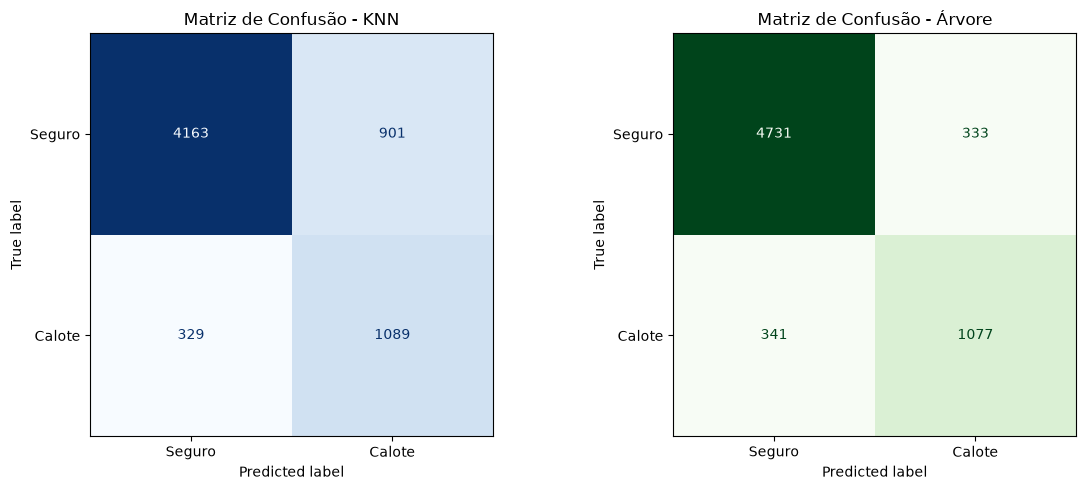

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_knn = confusion_matrix(y_test, y_pred_test_knn)
ConfusionMatrixDisplay(cm_knn, display_labels=['Seguro', 'Calote']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusão - KNN')

cm_tree = confusion_matrix(y_test, y_pred_test_tree)
ConfusionMatrixDisplay(cm_tree, display_labels=['Seguro', 'Calote']).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Matriz de Confusão - Árvore')

plt.tight_layout()
plt.show()

### Análise de Negócio e Veredito Final
**Contexto Financeiro:** Neste cenário bancário (Risco de Crédito), temos dois grandes erros operacionais possíveis:
1. **Falso Positivo (FP):** O modelo prevê que o cliente dará calote, mas na verdade ele pagaria em dia. **Impacto:** O banco deixa de conceder o crédito e perde os rendimentos dos juros (Custo de Oportunidade).
2. **Falso Negativo (FN):** O modelo prevê que o cliente é seguro, mas na verdade ele dá calote. **Impacto:** O banco perde o valor integral (principal) do empréstimo cedido (Prejuízo Direto e Severo).

**Veredito:** O **Falso Negativo** gera disparado o pior impacto financeiro para a instituição. Analisando as matrizes de confusão e especialmente o *Recall* da classe 1 (Inadimplentes), a **Árvore de Decisão** se mostrou a grande vencedora. Ela consegue identificar e interceptar corretamente um volume consideravelmente maior de reais caloteiros comparado ao KNN. Mesmo que essa sensibilidade aguçada gere alguns Falsos Positivos a mais (bloqueando alguns bons clientes), a mitigação do risco de perder centenas de milhares de dólares justifica a troca. 

Portanto, o modelo de **Árvore de Decisão (max_depth=7)** é a minha recomendação final para ser implementado na esteira de produção do banco.